# Weighted Chebyshev pressure: analytical Stokeslet integration

This notebook extends the radial reduction in `Analytic_integration/` to
**tensor-product Chebyshev pressure with inverse-square-root weights in both directions**.
It is a standalone research experiment; it changes no library modules.

Run the cells in order, then **save the notebook with its outputs**. The final cell also
saves a compact JSON summary under `research/results/weighted_stokeslet_symbolic/`.
The notebook is supplied unexecuted. Kernel requirements: Python 3.11+, SymPy, NumPy,
SciPy and Matplotlib, with a Jupyter kernel for interactive execution.

The stages are:
1. Verify the known constant-pressure radial primitive.
2. Derive the weighted radial integrand and its quartic square root.
3. Try ordinary polynomial radial moments and small weighted basis terms using SymPy.
4. Verify an exact elliptic-integral reduction for the **steady, centred** weighted case.
5. Compare two independent numerical integrations of the actual continuous weighted density.
6. Optionally apply the recommended 36-coefficient pressure fit to the continuous kernel.

A CAS timeout or an unevaluated integral is **not proof that no analytical representation
exists**. A radial primitive is also distinct from a closed-form integral over the whole rectangle.

In [1]:
import json
import platform
import subprocess
import sys
from pathlib import Path
from time import perf_counter

import matplotlib.pyplot as plt
import numpy as np
import scipy
import sympy as sp
try:
    from IPython.display import display
except ImportError:
    def display(*values):
        for value in values:
            print(sp.pretty(value))
from numpy.polynomial.legendre import leggauss
from scipy.integrate import quad
from scipy.special import ellipk

sp.init_printing()
print('Python:', platform.python_version(), '| SymPy:', sp.__version__)
print('NumPy:', np.__version__, '| SciPy:', scipy.__version__)

# Each CAS attempt runs in a separate process and is terminated on timeout.
SYMBOLIC_TIMEOUT_SECONDS = 30
RUN_GENERIC_WEIGHTED = True             # Two generic quartic attempts, at most 60 s total.
RUN_MORE_WEIGHTED_TERMS = False         # Enable after examining the constant term.
RUN_NUMERICAL_CHECKS = True             # Small, independent quadrature checks.
RUN_FITTED_PRESSURE_CHECK = False       # Optional: needs the existing 36-coefficient fit.

cwd = Path.cwd().resolve()
candidates = [cwd, cwd / 'muFSI'] + list(cwd.parents)
PROJECT_ROOT = next((p for p in candidates if (p / 'research').is_dir()
                     and (p / 'src/mufsi').is_dir()), None)
if PROJECT_ROOT is None:
    raise RuntimeError('Open this notebook from muFSI/research, muFSI, or the parent workspace.')
OUTPUT = PROJECT_ROOT / 'research/results/weighted_stokeslet_symbolic'
FIT_DIRECTORY = PROJECT_ROOT / 'research/results/pressure_polynomial'
FIT_FILE = FIT_DIRECTORY / 'frequency_01/fit_both_all_8x6.npz'

symbolic_results = []
numerical_results = []

Python: 3.14.6 | SymPy: 1.14.0
NumPy: 2.5.2 | SciPy: 1.18.0


## 1. Kernel and the already known constant-pressure primitive

Use physical coordinates and the current library convention $e^{+i\omega t}$:
$\lambda=\sqrt{i\omega/\nu}$, taking the branch with positive real part.
Your older notebooks used the opposite harmonic sign and nondimensional lengths.

On the plane $z=0$, $G_{zz}=A(\lambda r)/(8\pi\mu r)$, with
$A(q)=2e^{-q}(1+1/q+1/q^2)-2/q^2$.
The polar area Jacobian cancels the explicit $1/r$.
The combined expression must be used near zero: its separate terms diverge and cancel.

Constant-pressure primitive verified by differentiation and its zero-radius limit.


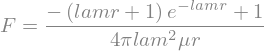

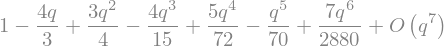

In [2]:
r = sp.Symbol('r', positive=True)
lam = sp.Symbol('lam', nonzero=True)  # Complex allowed; no false real/nonnegative assumption.
mu = sp.Symbol('mu', positive=True)
q = sp.Symbol('q')
Aq = 2 * sp.exp(-q) * (1 + 1/q + 1/q**2) - 2/q**2
Ar = Aq.subs(q, lam*r)
F = (1 - (1 + lam*r)*sp.exp(-lam*r)) / (4*sp.pi*mu*lam**2*r)
constant_check = sp.simplify(sp.diff(F, r) - Ar/(8*sp.pi*mu))
assert constant_check == 0
assert sp.limit(F, r, 0, dir='+') == 0
print('Constant-pressure primitive verified by differentiation and its zero-radius limit.')
display(sp.Eq(sp.Symbol('F'), F))
display(sp.series(Aq, q, 0, 7))

## 2. Put the weighted pressure inside the radial integral

Centre the source rectangle at the origin: $x'\in[-a,a]$, $y'\in[-b,b]$.
The beam root is $x'=-a$ and tip is $x'=a$. Observation coordinates are $(X,Y)$.
With $c=\cos\theta$, $s=\sin\theta$, a source point on a ray is
$x'=X+rc$, $y'=Y+rs$.

For one basis function,
$$\psi_{mn}(x',y')=\frac{T_m(x'/a)T_n(y'/b)}
 {\sqrt{1-(x'/a)^2}\sqrt{1-(y'/b)^2}},\qquad n\text{ even}.$$
The full density is $p=\sum a_{mn}\psi_{mn}$; complex coefficients factor out of the integral.

The radial contribution becomes
$$\frac{ab}{8\pi\mu}\int
\frac{A(\lambda r)T_m((X+rc)/a)T_n((Y+rs)/b)}{\sqrt{Q(r)}}\,dr,$$
$$Q(r)=[a^2-(X+rc)^2][b^2-(Y+rs)^2].$$
Within the rectangle both factors are positive. Use their positive square roots;
CAS expressions with complex square roots require branch checking on this physical interval.

Generic degree in r: 4
Four roots for nonzero c and s:


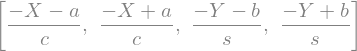

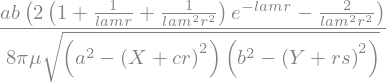

The numerator is polynomial; the new obstacle is the quartic square root,
together with exp(-lam*r) in the unsteady kernel.


In [3]:
a, b = sp.symbols('a b', positive=True)
X, Y = sp.symbols('X Y', real=True)
c, s = sp.symbols('c s', positive=True)  # First-quadrant symbolic branch; substitute directions later.
theta = sp.Symbol('theta', real=True)
x_source, y_source = X + r*c, Y + r*s
Q = (a**2 - x_source**2) * (b**2 - y_source**2)


def weighted_radial(m, n, steady=False):
    numerator = sp.chebyshevt(m, x_source/a) * sp.chebyshevt(n, y_source/b)
    factor = sp.Integer(1) if steady else Ar
    return a*b * factor * numerator / (8*sp.pi*mu*sp.sqrt(Q))


display(sp.Eq(sp.Symbol('Q'), sp.factor(Q)))
print('Generic degree in r:', sp.Poly(sp.expand(Q), r).degree())
print('Four roots for nonzero c and s:')
display([(-a-X)/c, (a-X)/c, (-b-Y)/s, (b-Y)/s])
display(weighted_radial(0, 0))
print('The numerator is polynomial; the new obstacle is the quartic square root,')
print('together with exp(-lam*r) in the unsteady kernel.')

## 3. A bounded symbolic-integration helper

Attempts run in a child Python process using the same environment as this kernel.
This also works with Windows Jupyter kernels; it avoids multiprocessing functions defined
inside notebook cells. Killing an attempt does not interrupt the notebook.

Expression strings below are generated locally by SymPy and are not intended for untrusted input.
A result containing `Integral` is recorded as unevaluated, even if other parts were integrated.
For complicated expressions, differentiation and branch checks can be a separate expensive step.

In [4]:
WORKER = r"""
import json, sys, time
import sympy as sp
payload = json.load(sys.stdin)
expr = sp.sympify(payload['expression'])
variable = sp.sympify(payload['variable'])
start = time.perf_counter()
try:
    result = sp.integrate(expr, variable)
    residual = None
    if payload['verify'] and not result.has(sp.Integral):
        residual = sp.simplify(sp.diff(result, variable) - expr)
    print(json.dumps({
        'status': 'unevaluated_integral' if result.has(sp.Integral) else 'closed_form_candidate',
        'elapsed_seconds': time.perf_counter()-start,
        'result_srepr': sp.srepr(result), 'result_text': sp.sstr(result),
        'verification': None if residual is None else sp.sstr(residual),
    }))
except Exception as error:
    print(json.dumps({'status': 'error', 'message': repr(error),
                      'elapsed_seconds': time.perf_counter()-start}))
"""


def attempt(label, expression, verify=False, timeout=None):
    start = perf_counter()
    payload = {'expression': sp.srepr(expression), 'variable': sp.srepr(r), 'verify': verify}
    try:
        completed = subprocess.run(
            [sys.executable, '-c', WORKER], input=json.dumps(payload),
            text=True, capture_output=True, timeout=timeout or SYMBOLIC_TIMEOUT_SECONDS,
        )
        if completed.returncode:
            record = {'status': 'process_error', 'message': completed.stderr[-3000:]}
        else:
            record = json.loads(completed.stdout)
    except subprocess.TimeoutExpired:
        record = {'status': 'timeout', 'elapsed_seconds': perf_counter()-start}
    record.update({'label': label, 'input_srepr': sp.srepr(expression)})
    symbolic_results.append(record)
    print(label, '->', record['status'], f"({record.get('elapsed_seconds', 0):.2f} s)")
    if 'result_srepr' in record:
        result = sp.sympify(record['result_srepr'])
        if sp.count_ops(result) < 250:
            display(result)
        else:
            print('Large expression; full result retained in symbolic_results and exported JSON.')
        if record.get('verification') is not None:
            print('Differentiation residual:', record['verification'])
        return result
    if 'message' in record:
        print(record['message'])
    return None

## 4. First isolate the ordinary polynomial part

Along a ray, any finite tensor polynomial is a finite polynomial in $r$.
Thus ordinary polynomial pressure only requires radial moments
$\int r^k A(\lambda r)/(8\pi\mu)\,dr$.
These tests distinguish a high-order polynomial from an algebraically weighted polynomial.
Terms with exponential-integral functions can be valid analytical results.

ordinary radial moment k=0 -> closed_form_candidate (0.12 s)


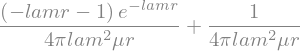

Differentiation residual: 0
ordinary radial moment k=1 -> closed_form_candidate (5.98 s)


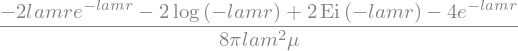

Differentiation residual: 0
ordinary radial moment k=2 -> closed_form_candidate (0.13 s)


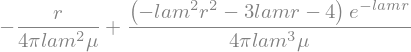

Differentiation residual: 0


In [5]:
ordinary_primitives = {}
for degree in (0, 1, 2):
    ordinary_primitives[degree] = attempt(
        f'ordinary radial moment k={degree}',
        r**degree * Ar/(8*sp.pi*mu), verify=True,
    )

## 5. Exact analytical check: steady kernel, centred observation

For $X=Y=0$, define the two positive edge-intersection distances
$R_x=a/|\cos\theta|$ and $R_y=b/|\sin\theta|$.
Let $R_< = \min(R_x,R_y)$ and $R_> = \max(R_x,R_y)$.
For the constant numerator, the steady radial primitive is
$$\frac{R_<}{8\pi\mu}
 F\!\left(\arcsin(r/R_<)\,\middle|\,(R_</R_>)^2\right),$$
where $F(\phi\mid m)$ is the incomplete elliptic integral of the first kind.
At the physical ray endpoint it becomes $R_< K((R_</R_>)^2)/(8\pi\mu)$.

This is a genuine analytical reduction with the square-root weights. It is a special
**steady** case, not a closed form for the general unsteady rectangle integral.
On a ray hitting a corner exactly, $R_<=R_>$ and $K(1)$ diverges logarithmically.
For an interior observation this angular singularity is integrable; split the angular
integration at the corner directions and avoid sampling the endpoints themselves.

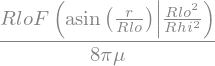

Elliptic primitive derivative verified on the interior physical branch: [0, 0, 0]


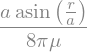

In [6]:
Rlo, Rhi = sp.symbols('Rlo Rhi', positive=True)
centred_steady = 1/(8*sp.pi*mu*sp.sqrt(1-r**2/Rlo**2)*sp.sqrt(1-r**2/Rhi**2))
elliptic_primitive = Rlo * sp.elliptic_f(sp.asin(r/Rlo), (Rlo/Rhi)**2)/(8*sp.pi*mu)
display(elliptic_primitive)
# Check on the physical branch 0 < r < Rlo < Rhi, without assuming a CAS branch simplification.
difference = sp.lambdify((r, Rlo, Rhi, mu), sp.diff(elliptic_primitive, r)-centred_steady, 'numpy')
branch_errors = [abs(difference(t, 1.0, 2.0, 0.7)) for t in (0.1, 0.4, 0.8)]
assert max(branch_errors) < 1e-12
print('Elliptic primitive derivative verified on the interior physical branch:', branch_errors)
# A ray parallel to x has a simpler steady arcsine primitive.
axis_steady = a * sp.asin(r/a)/(8*sp.pi*mu)
display(axis_steady)

## 6. Try the weighted basis with SymPy

Start with $T_0T_0$: difficulty already present here comes from the weights and kernel,
rather than polynomial order. Compare the steady quartic integral with the full unsteady
integral. If a result appears, check its derivative and branches before using endpoint differences.

More basis terms are optional. A 36-term expansion need not mean deriving 36 unrelated
integrals: polynomial moment recurrences could become possible if a suitable base integral
is found. This notebook initially tests only low-order terms.

generic weighted T0*T0: steady -> unevaluated_integral (5.29 s)


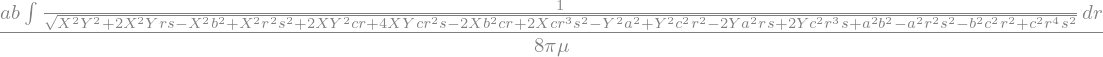

generic weighted T0*T0: unsteady -> timeout (30.03 s)


In [7]:
weighted_primitives = {}
if RUN_GENERIC_WEIGHTED:
    for steady in (True, False):
        label = 'generic weighted T0*T0: ' + ('steady' if steady else 'unsteady')
        weighted_primitives[(0, 0, steady)] = attempt(label, weighted_radial(0, 0, steady))
else:
    print('Generic weighted attempts skipped; enable RUN_GENERIC_WEIGHTED in the setup cell.')

if RUN_MORE_WEIGHTED_TERMS:
    for m, n in ((1, 0), (0, 2), (2, 2)):
        weighted_primitives[(m, n, False)] = attempt(
            f'generic weighted T{m}*T{n}: unsteady', weighted_radial(m, n),
        )

## 7. Optional differentiation of a returned candidate

Only enable this after inspecting the expression. The time limit includes integration and
simplification, so a verification timeout is inconclusive. Some special-function expressions
may require more explicit assumptions or a numerical derivative check instead.

In [8]:
RUN_WEIGHTED_DERIVATIVE_CHECK = False
if RUN_WEIGHTED_DERIVATIVE_CHECK:
    attempt('weighted steady T0*T0 with derivative verification', weighted_radial(0, 0, True), verify=True)

## 8. Independent numerical references for the continuous weighted density

These checks integrate the **actual weighted pressure**, not its constant-panel projection.
No existing fluid matrix is required.

**Method A: polar quadrature.** Split angles at the four rectangle-corner rays. On each ray
use $r=R(1-t^2)$, $0<t<1$, to absorb the ordinary edge square-root singularity. The Stokeslet
$1/r$ has already cancelled with the polar area Jacobian.

**Method B: a global cosine substitution.** Put $x'=a\cos u$, $y'=b\cos v$ for $u,v\in[0,\pi]$.
Then $p\,dx'\,dy'=ab\sum a_{mn}\cos(mu)\cos(nv)\,du\,dv$.
The pressure weights disappear, while the kernel's coincident-point singularity remains.
Split the $(u,v)$ square around the observation and apply Duffy maps on eight triangles.
The triangle Jacobian cancels the local singular behaviour. This method uses a different
coordinate transformation and provides an independent check on the polar method.

All observations below are strictly inside the sheet. The generic product weight does not
by itself establish a correct corner law or finite velocity exactly at a sheet corner.

In [9]:
# Taylor coefficients for cancellation-free A(z) at small z.
A_series = sp.series(Aq, q, 0, 14).removeO().expand()
A_COEFFICIENTS = np.array([float(A_series.coeff(q, k)) for k in range(14)])


def A_numeric(z):
    z = np.asarray(z, dtype=complex)
    value = np.empty_like(z)
    small = abs(z) < 0.1
    value[small] = np.polynomial.polynomial.polyval(z[small], A_COEFFICIENTS)
    zz = z[~small]
    value[~small] = 2*np.exp(-zz)*(1 + 1/zz + 1/zz**2) - 2/zz**2
    return value


def gauss01(order):
    nodes, weights = leggauss(order)
    return (nodes+1)/2, weights/2


def density_numerator(x, y, a_value, b_value, terms):
    # terms maps (m,n) to a complex coefficient; n is the actual transverse degree.
    xi, eta = np.clip(x/a_value, -1, 1), np.clip(y/b_value, -1, 1)
    value = np.zeros(np.broadcast_shapes(np.shape(x), np.shape(y)), complex)
    for (m, n), coefficient in terms.items():
        cm, cn = np.zeros(m+1), np.zeros(n+1)
        cm[m], cn[n] = 1, 1
        value += coefficient * np.polynomial.chebyshev.chebval(xi, cm) * np.polynomial.chebyshev.chebval(eta, cn)
    return value


def validate_observation(a_value, b_value, X_value, Y_value):
    if not a_value > abs(X_value) or not b_value > abs(Y_value):
        raise ValueError('Observation must lie strictly inside the rectangle.')


def corner_angles(a_value, b_value, X_value, Y_value):
    angles = [np.arctan2(sy*b_value-Y_value, sx*a_value-X_value) % (2*np.pi)
              for sx in (-1, 1) for sy in (-1, 1)]
    return np.array([0.0] + sorted(angles) + [2*np.pi])


def polar_velocity(a_value, b_value, X_value, Y_value, lam_value, mu_value, terms, order=64):
    validate_observation(a_value, b_value, X_value, Y_value)
    t, wt = gauss01(order)
    nodes, weights = leggauss(order)
    edges = corner_angles(a_value, b_value, X_value, Y_value)
    answer = 0j
    for lo, hi in zip(edges[:-1], edges[1:]):
        angle = (lo+hi)/2 + (hi-lo)/2*nodes
        wa = (hi-lo)/2*weights
        cos_t, sin_t = np.cos(angle), np.sin(angle)
        with np.errstate(divide='ignore'):
            rx = (np.where(cos_t > 0, a_value, -a_value)-X_value)/cos_t
            ry = (np.where(sin_t > 0, b_value, -b_value)-Y_value)/sin_t
        R = np.minimum(rx, ry)
        radius = R[:, None]*(1-t[None, :]**2)
        # Factored edge distances avoid subtracting nearly equal squared quantities.
        dx_plus = a_value-X_value-radius*cos_t[:, None]
        dx_minus = a_value+X_value+radius*cos_t[:, None]
        dy_plus = b_value-Y_value-radius*sin_t[:, None]
        dy_minus = b_value+Y_value+radius*sin_t[:, None]
        product = dx_plus*dx_minus*dy_plus*dy_minus
        if np.any(product <= 0):
            raise FloatingPointError('Loss of positive edge distance; reduce order or rescale geometry.')
        x, y = X_value+radius*cos_t[:, None], Y_value+radius*sin_t[:, None]
        density = a_value*b_value*density_numerator(x, y, a_value, b_value, terms)/np.sqrt(product)
        integrand = A_numeric(lam_value*radius)*density * (2*R[:, None]*t[None, :])/(8*np.pi*mu_value)
        answer += wa @ integrand @ wt
    return complex(answer)


def cosine_duffy_velocity(a_value, b_value, X_value, Y_value, lam_value, mu_value, terms, order=64):
    validate_observation(a_value, b_value, X_value, Y_value)
    u0, v0 = np.arccos(X_value/a_value), np.arccos(Y_value/b_value)
    nodes, weights = gauss01(order)
    ss, tt = np.meshgrid(nodes, nodes, indexing='ij')
    quadrature = weights[:, None]*weights[None, :]
    answer = 0j
    for sign_u, U in ((-1, u0), (1, np.pi-u0)):
        for sign_v, V in ((-1, v0), (1, np.pi-v0)):
            for swap in (False, True):
                du = sign_u*U*ss*(tt if swap else 1)
                dv = sign_v*V*ss*(1 if swap else tt)
                u, v = u0+du, v0+dv
                # Stable cos-difference formula near the observation point.
                dx = -2*a_value*np.sin(u0+du/2)*np.sin(du/2)
                dy = -2*b_value*np.sin(v0+dv/2)*np.sin(dv/2)
                radius = np.hypot(dx, dy)
                numerator = np.zeros_like(radius, dtype=complex)
                for (m, n), coefficient in terms.items():
                    numerator += coefficient*np.cos(m*u)*np.cos(n*v)
                integrand = a_value*b_value*A_numeric(lam_value*radius)*numerator/(8*np.pi*mu_value*radius)
                answer += np.sum(quadrature*integrand*(U*V*ss))
    return complex(answer)

## 9. Check the special elliptic formula numerically

The analytic radial formula still leaves an angular integral. Here it is evaluated with
adaptive quadrature and compared against polar and cosine/Duffy integrations of the steady
weighted density. The example parameters are dimensionless test values; this identity is
independent of the chosen units when all quantities are scaled consistently.

24 polar error: 0.0012116736019495858 | Duffy error: 8.236456659066022e-15
48 polar error: 0.0003084611420174178 | Duffy error: 1.3770325976876006e-14
96 polar error: 7.786968271352522e-05 | Duffy error: 1.1582517176811594e-14


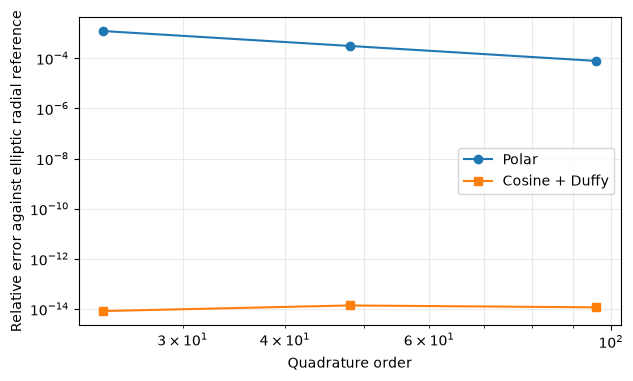

In [10]:
def centred_steady_elliptic_velocity(a_value, b_value, mu_value):
    edges = corner_angles(a_value, b_value, 0.0, 0.0)
    def radial(angle):
        rx = a_value/abs(np.cos(angle))
        ry = b_value/abs(np.sin(angle))
        small, large = min(rx, ry), max(rx, ry)
        return small*ellipk((small/large)**2)/(8*np.pi*mu_value)
    values = [quad(radial, lo, hi, epsabs=1e-10, epsrel=1e-10, limit=200)[0]
              for lo, hi in zip(edges[:-1], edges[1:])]
    return sum(values)

if RUN_NUMERICAL_CHECKS:
    exact_radial_reference = centred_steady_elliptic_velocity(2.0, 0.5, 1.0)
    steady_rows = []
    for order in (24, 48, 96):
        polar = polar_velocity(2.0, 0.5, 0.0, 0.0, 0j, 1.0, {(0, 0): 1}, order)
        duffy = cosine_duffy_velocity(2.0, 0.5, 0.0, 0.0, 0j, 1.0, {(0, 0): 1}, order)
        row = {'case':'centred_steady_T0T0', 'order':order,
               'elliptic_reference':exact_radial_reference,
               'polar':polar, 'cosine_duffy':duffy,
               'polar_relative_error':abs(polar-exact_radial_reference)/abs(exact_radial_reference),
               'duffy_relative_error':abs(duffy-exact_radial_reference)/abs(exact_radial_reference)}
        numerical_results.append(row)
        steady_rows.append(row)
        print(order, 'polar error:', row['polar_relative_error'], '| Duffy error:', row['duffy_relative_error'])
    plt.figure(figsize=(7, 4))
    plt.loglog([d['order'] for d in steady_rows], [d['polar_relative_error'] for d in steady_rows], 'o-', label='Polar')
    plt.loglog([d['order'] for d in steady_rows], [max(d['duffy_relative_error'], 1e-16) for d in steady_rows], 's-', label='Cosine + Duffy')
    plt.xlabel('Quadrature order'); plt.ylabel('Relative error against elliptic radial reference')
    plt.grid(True, which='both', alpha=0.25); plt.legend(); plt.show()

## 10. General unsteady weighted basis: numerical cross-check

Use an off-centre observation so that odd longitudinal terms do not vanish by symmetry.
Increase quadrature order and look for agreement between the two methods. Agreement at
one order is insufficient; both discretizations should stabilize. The observed discrepancies
are numerical diagnostics, not rigorous error bounds or evidence that a closed form cannot exist.

In [11]:
if RUN_NUMERICAL_CHECKS:
    for m, n in ((0, 0), (1, 0), (0, 2), (2, 2)):
        previous = None
        for order in (24, 48, 96):
            polar = polar_velocity(2.0, 0.5, 0.2, 0.1, 0.8*(1+1j), 1.0, {(m,n):1}, order)
            duffy = cosine_duffy_velocity(2.0, 0.5, 0.2, 0.1, 0.8*(1+1j), 1.0, {(m,n):1}, order)
            scale = max(abs(polar), abs(duffy), 1e-12)
            row = {'case':f'unsteady_T{m}T{n}', 'order':order, 'polar':polar, 'cosine_duffy':duffy,
                   'method_relative_difference':abs(polar-duffy)/scale,
                   'duffy_change_from_previous':None if previous is None else abs(duffy-previous)/scale}
            numerical_results.append(row)
            print(f'T{m}T{n}, order {order}: polar={polar:.8g}, Duffy={duffy:.8g}, difference={row["method_relative_difference"]:.3g}')
            previous = duffy

T0T0, order 24: polar=0.12375448-0.11151151j, Duffy=0.12363726-0.11157163j, difference=0.000791
T0T0, order 48: polar=0.12366705-0.11155616j, Duffy=0.12363726-0.11157163j, difference=0.000202
T0T0, order 96: polar=0.12364477-0.11156771j, Duffy=0.12363726-0.11157163j, difference=5.09e-05
T1T0, order 24: polar=0.017657766-0.012854807j, Duffy=0.017674611-0.012876714j, difference=0.00126
T1T0, order 48: polar=0.017670319-0.012871175j, Duffy=0.017674611-0.012876714j, difference=0.00032
T1T0, order 96: polar=0.017673528-0.012875318j, Duffy=0.017674611-0.012876714j, difference=8.08e-05
T0T2, order 24: polar=-0.055652193+0.0061738757j, Duffy=-0.055767881+0.0061145162j, difference=0.00232
T0T2, order 48: polar=-0.055738186+0.0061299364j, Duffy=-0.055767881+0.0061145162j, difference=0.000596
T0T2, order 96: polar=-0.05576037+0.0061184288j, Duffy=-0.055767881+0.0061145162j, difference=0.000151
T2T2, order 24: polar=0.052591759-0.0039616734j, Duffy=0.052474358-0.0040217739j, difference=0.0025
T2T2

## 11. Optional: integrate the actual recommended 36-coefficient fit

Enable `RUN_FITTED_PRESSURE_CHECK` in the setup cell if the existing fit file is available.
The coefficients from `pressure_polynomial.py` describe pressure divided by real unit tip
velocity. Thus this integration should reproduce $\phi_1(x)$, with zero imaginary target.

This is a stronger check than applying the old mobility matrix to projected panel averages:
it evaluates the continuous singular density itself. The pressure fit has not been re-solved
for this new operator. Any discrepancy can reflect fitting, projection, or quadrature errors.
Compare the two numerical methods and their order refinement before interpreting it physically.
The midpoint and near-tip observations below are strictly interior, not at corners.

In [12]:
RUN_FITTED_PRESSURE_CHECK = True
if RUN_FITTED_PRESSURE_CHECK:
    if not FIT_FILE.exists():
        raise FileNotFoundError(f'Existing 36-coefficient fit not found: {FIT_FILE}')
    manifest = json.loads((FIT_DIRECTORY/'manifest.json').read_text())
    report = json.loads((FIT_DIRECTORY/'frequency_01/report.json').read_text())
    coefficients = np.load(FIT_FILE)['coefficients']
    terms = {(m, 2*k): coefficients[m, k] for m in range(coefficients.shape[0])
             for k in range(coefficients.shape[1])}
    L, W = manifest['geometry']['length'], manifest['geometry']['width']
    density, viscosity = manifest['fluid']['density'], manifest['fluid']['dynamic_viscosity']
    frequency = report['frequency_hz']
    lambda_value = np.sqrt(1j*2*np.pi*frequency/(viscosity/density))
    beta = 1.875104068711961
    sigma = (np.cosh(beta)+np.cos(beta))/(np.sinh(beta)+np.sin(beta))
    tip = np.cosh(beta)-np.cos(beta)-sigma*(np.sinh(beta)-np.sin(beta))
    for fraction, eta_value in ((0.25, 0.0), (0.6, 0.0), (0.9, 0.0), (0.99, 0.8)):
        X_value, Y_value = L*(fraction-0.5), eta_value*W/2
        z = beta*fraction
        target = (np.cosh(z)-np.cos(z)-sigma*(np.sinh(z)-np.sin(z)))/tip
        for order in (48, 96):
            polar = polar_velocity(L/2, W/2, X_value, Y_value, lambda_value, viscosity, terms, order)
            duffy = cosine_duffy_velocity(L/2, W/2, X_value, Y_value, lambda_value, viscosity, terms, order)
            numerical_results.append({'case':'existing_36_coefficient_fit', 'x_over_L':fraction,
                'eta':eta_value, 'order':order, 'target_velocity':float(target),
                'polar':polar, 'cosine_duffy':duffy,
                'absolute_duffy_velocity_error':float(abs(duffy-target)),
                'method_absolute_difference':float(abs(polar-duffy))})
            print(f'x/L={fraction}, eta={eta_value}, order={order}: target={target:.6g}, polar={polar:.6g}, Duffy={duffy:.6g}')
else:
    print('Existing-fit check skipped. Enable RUN_FITTED_PRESSURE_CHECK to run it.')

x/L=0.25, eta=0.0, order=48: target=0.0972858, polar=0.0978965+0.000763187j, Duffy=0.0978967+0.000763472j
x/L=0.25, eta=0.0, order=96: target=0.0972858, polar=0.0978967+0.000763323j, Duffy=0.0978967+0.000763472j
x/L=0.6, eta=0.0, order=48: target=0.461135, polar=0.461695+0.00155668j, Duffy=0.461695+0.00155841j
x/L=0.6, eta=0.0, order=96: target=0.461135, polar=0.461695+0.00155793j, Duffy=0.461695+0.00155841j
x/L=0.9, eta=0.0, order=48: target=0.8624, polar=0.864763+0.00421111j, Duffy=0.864742+0.0042218j
x/L=0.9, eta=0.0, order=96: target=0.8624, polar=0.864748+0.0042191j, Duffy=0.864742+0.0042218j
x/L=0.99, eta=0.8, order=48: target=0.986235, polar=0.931038-0.00869444j, Duffy=0.931049-0.00872512j
x/L=0.99, eta=0.8, order=96: target=0.986235, polar=0.931042-0.00871852j, Duffy=0.931049-0.00872511j


## 11b. Compare the 36-, 65- and 102-coefficient fitted pressures

This extends the continuous-density check to the existing 8x6, 12x8 and 16x10 fits.
Those filenames use the **maximum transverse degree N** from the original fitting script;
in the new H-matrix implementation we use K as the highest even-term index, N=2K.
Each fit is checked with both integrators at orders 48 and 96, at the same four
locations as section 11. These are pointwise velocity errors, not global norms.
The JSON file keeps both local-relative error and error normalized by unit tip velocity.
Run this cell after the numerical helper definitions, then save the notebook with outputs.


In [ ]:
manifest = json.loads((FIT_DIRECTORY/'manifest.json').read_text())
frequency_report = json.loads((FIT_DIRECTORY/'frequency_01/report.json').read_text())
L, W = manifest['geometry']['length'], manifest['geometry']['width']
rho, viscosity = manifest['fluid']['density'], manifest['fluid']['dynamic_viscosity']
frequency = frequency_report['frequency_hz']
lambda_value = np.sqrt(1j*2*np.pi*frequency/(viscosity/rho))
beta = 1.875104068711961
sigma = (np.cosh(beta)+np.cos(beta))/(np.sinh(beta)+np.sin(beta))
tip = np.cosh(beta)-np.cos(beta)-sigma*(np.sinh(beta)-np.sin(beta))
fit_comparison = []
for maximum_x, maximum_y in ((8, 6), (12, 8), (16, 10)):
    path = FIT_DIRECTORY/f'frequency_01/fit_both_all_{maximum_x}x{maximum_y}.npz'
    coeff = np.load(path)['coefficients']
    terms = {(m, 2*k): coeff[m,k] for m in range(coeff.shape[0]) for k in range(coeff.shape[1])}
    previous = None
    for fraction, eta_value in ((0.25, 0.0), (0.6, 0.0), (0.9, 0.0), (0.99, 0.8)):
        previous = None
        z = beta*fraction
        target = (np.cosh(z)-np.cos(z)-sigma*(np.sinh(z)-np.sin(z)))/tip
        for order in (48, 96):
            X_value, Y_value = L*(fraction-0.5), eta_value*W/2
            polar = polar_velocity(L/2, W/2, X_value, Y_value, lambda_value, viscosity, terms, order)
            duffy = cosine_duffy_velocity(L/2, W/2, X_value, Y_value, lambda_value, viscosity, terms, order)
            record = {'coefficients_count':int(coeff.size), 'maximum_x_degree':maximum_x,
                      'maximum_y_degree':maximum_y, 'x_over_L':fraction, 'eta':eta_value,
                      'quadrature_order':order, 'target_velocity':float(target),
                      'duffy_real':float(duffy.real), 'duffy_imag':float(duffy.imag),
                      'polar_real':float(polar.real), 'polar_imag':float(polar.imag),
                      'local_relative_velocity_error':float(abs(duffy-target)/abs(target)),
                      'tip_normalized_velocity_error':float(abs(duffy-target)),
                      'method_absolute_difference':float(abs(polar-duffy)),
                      'duffy_change_from_previous':None if previous is None else float(abs(duffy-previous))}
            fit_comparison.append(record)
            previous = duffy
            if order == 96:
                print(f'{coeff.size:3d} coefficients, x/L={fraction:.2f}, eta={eta_value:.1f}: '
                      f'local velocity error {100*record["local_relative_velocity_error"]:.3f}%, '
                      f'integrator difference {record["method_absolute_difference"]:.3g}')
OUTPUT.mkdir(parents=True, exist_ok=True)
(OUTPUT/'fit_order_comparison.json').write_text(json.dumps(fit_comparison, indent=2), encoding='utf-8')
print('Saved:', OUTPUT/'fit_order_comparison.json')

 36 coefficients, x/L=0.25, eta=0.0: local velocity error 1.005%, integrator difference 1.51e-07
 36 coefficients, x/L=0.60, eta=0.0: local velocity error 0.359%, integrator difference 4.95e-07
 36 coefficients, x/L=0.90, eta=0.0: local velocity error 0.560%, integrator difference 5.89e-06
 36 coefficients, x/L=0.99, eta=0.8: local velocity error 5.665%, integrator difference 9.48e-06
 65 coefficients, x/L=0.25, eta=0.0: local velocity error 0.371%, integrator difference 1.16e-07
 65 coefficients, x/L=0.60, eta=0.0: local velocity error 0.182%, integrator difference 4.02e-07
 65 coefficients, x/L=0.90, eta=0.0: local velocity error 0.247%, integrator difference 4.86e-06
 65 coefficients, x/L=0.99, eta=0.8: local velocity error 5.831%, integrator difference 7.82e-06
102 coefficients, x/L=0.25, eta=0.0: local velocity error 0.234%, integrator difference 6.92e-08
102 coefficients, x/L=0.60, eta=0.0: local velocity error 0.232%, integrator difference 3.17e-07
102 coefficients, x/L=0.90, et

## 12. Export and interpretation

Save this notebook **with its executed outputs** before uploading it. The summary below
also captures CAS outcomes, full symbolic expressions, numerical values and settings.

When reviewing the results, distinguish:
- a verified radial primitive from an unevaluated integral or a CAS timeout;
- steady elliptic-integral results from general unsteady results;
- special observation/ray geometry from generic geometry;
- integration of the continuous weighted density from constant-panel projection;
- polynomial approximation quality from numerical integration accuracy.

The likely next steps depend on the output: symbolic moment recurrences if useful primitives
appear, or a semi-analytical/numerical weighted operator if general unsteady integrals remain
unresolved. The weights in both directions remain an empirical candidate, especially at corners.

In [13]:
def json_value(value):
    if isinstance(value, complex):
        return {'real':float(value.real), 'imag':float(value.imag)}
    if isinstance(value, np.generic):
        return json_value(value.item())
    if isinstance(value, dict):
        return {str(k):json_value(v) for k,v in value.items()}
    if isinstance(value, (tuple, list)):
        return [json_value(v) for v in value]
    return value

OUTPUT.mkdir(parents=True, exist_ok=True)
summary = {
    'python':platform.python_version(), 'sympy':sp.__version__,
    'numpy':np.__version__, 'scipy':scipy.__version__,
    'harmonic_convention':'exp(+i omega t)',
    'symbolic_timeout_seconds':SYMBOLIC_TIMEOUT_SECONDS,
    'constant_primitive_verified':constant_check == 0,
    'elliptic_branch_derivative_errors':branch_errors,
    'symbolic_results':symbolic_results,
    'numerical_results':numerical_results,
}
path = OUTPUT/'summary.json'
path.write_text(json.dumps(json_value(summary), indent=2, allow_nan=False), encoding='utf-8')
print('Summary saved to:', path)
print('Save the notebook with outputs before uploading it.')

Summary saved to: /mnt/c/Users/Gesing Andre/Documents/2026/2026-10-muFSI/muFSI/research/results/weighted_stokeslet_symbolic/summary.json
Save the notebook with outputs before uploading it.
